<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Trabajo Practico de Laboratorio 2</h1>
    <h2>Filtrado Digital</h2>
    <h3>Teoria de los Circuitos II - R4052</h3>
    <h3>Grupo E</h3>
    <br>
    <b>Integrantes:</b><br>
    Fabian Alexander Iturrizaga Meza<br>
    Juan Manuel Contreras<br>
    Lucas Pedro Gallero<br>
    Brian Junior Rojas Peredo<br>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: Cesar Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="../../tareas_semanales/TS3/tarea_semanal_3/img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Informe de laboratorio

Este notebook documenta el diseño, la simulacion, la seleccion de componentes y la verificacion experimental del filtro asignado al grupo E.

## Consigna

### Librería CMSIS

El filtro digital en sí mismo es un algoritmo. En nuestro caso, para simplificar la tarea, vamos a instanciar funciones de la librería de procesamiento digital de ARM [CMSIS-DSP](https://arm-software.github.io/CMSIS_6/latest/General/index.html):

- `arm_fir_f32`
- `arm_biquad_cascade_df1_f32`

👉 El IDE para trabajar con el MCU es el [STM32CubeIDE](https://www.st.com/en/development-tools/stm32cubeide.html).  
👉 El workspace del proyecto lo pueden descargar [acá](https://drive.google.com/file/d/1gx6FtM1LSxWALKoZYPS61EnUTvyE7NhT/view?usp=drive_link).

---

### Plantillas

| Filtro (OPAMP) | Función de Aproximación | $f_p$ | $f_s$ | $\alpha_{max}$ | $\alpha_{min}$ |
| :---: | :--- | :---: | :---: | :---: | :---: |
| A | Chebyshev | $100\text{ Hz}$ | $300\text{ Hz}$ | $1\text{ dB}$ | $60\text{ dB}$ |

| Filtro (OPAMP) | Tipo | $f_{notch}$ | $BW \text{ @ } 3\text{dB}$ |
| :---: | :---: | :---: | :---: |
| B | Notch | $50\text{ Hz}$ | $1\text{ Hz}$ |

---

### 🖥️ Análisis y Simulación (*Pre-Lab*)

1. Obtener los coeficientes del filtro digital usando la función [`iirdesign`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html#scipy.signal.iirdesign).
2. Simulación de la función transferencia en Python para una frecuencia de sampling ***configurable***.

---

### 🎛️ Implementación (*STM32*)

1. Compilar sin errores el proyecto en el IDE.

---

### 🔬 Medición (*In-Lab*)

<div align="center">
  <img src="img/esquema_filtro_dsp_stm32.jpg" alt="Esquema de medición y kit de desarrollo STM32" width="40%"/>
</div>

*Figura: Esquema completo de la cadena de procesamiento digital y conexiones del kit de desarrollo STM32 para la práctica de laboratorio.*

Las conexiones con el kit de desarrollo se detallan a continuación:

| # PIN | DESCRIPCIÓN |
| :--- | :--- |
| **CN6 - PIN 6** | GND |
| **CN6 - PIN 4** | +5 VDC |
| **CN8 - PIN 1** | ADC_IN |
| **CN8 - PIN 3** | DAC_OUT |

## Indice

> **Nota:** los hipervinculos funcionan correctamente en JupyterLab y VS Code abiertos localmente.

1. [Obtención de los coeficientes y simulación en Python](#p1)
2. [Implementación en el STM32 con la librería CMSIS](#p2)
3. [Práctica de laboratorio](#p3)
4. [Conclusiones](#p4)

<a id="p1"></a>

***

## 1. Obtención de los coeficientes y simulación en Python




Este script automatiza el cálculo de coeficientes para filtros digitales IIR y los adapta al formato específico requerido por los microcontroladores ARM.

A continuación se detalla el funcionamiento de las partes clave del código, seguido del script con comentarios exhaustivos línea por línea.

### Flujo de Funcionamiento del Script

- **Definición de Parámetros:** Establece la frecuencia de muestreo del sistema (`FS_SAMPLING`) y las plantillas de diseño para dos filtros: un pasabajos Chebyshev (Filtro A) y un rechaza-banda o *Notch* (Filtro B).
- **Diseño de Filtros (SciPy):** Utiliza las funciones `signal.iirdesign` e `signal.iirnotch` para calcular matemáticamente los coeficientes de los filtros. El resultado se obtiene en formato **SOS (Second-Order Sections o Biquads)**. Agrupar los filtros en etapas de segundo orden minimiza los errores de cuantización y problemas de inestabilidad numérica que ocurren al implementar filtros de orden alto en hardware de 32 bits.
- **Conversión a CMSIS-DSP:** La función `cmsis_sos_from_scipy_sos` es el núcleo del adaptador. La ecuación en diferencias estándar de SciPy resta los coeficientes pasados de la salida ($a_1, a_2$), mientras que la implementación de ARM CMSIS-DSP los suma. Por ello, el script extrae los 6 coeficientes de SciPy, descarta $a_0$ (que siempre es 1) e invierte el signo de $a_1$ y $a_2$.
- **Generación de Código C y Gráficos:** La función `emit_c_array` toma el arreglo de coeficientes procesado y lo imprime en la consola formateado como código C listo para copiar y pegar en `..\filtro_xxx\TCII_Filter-NUCLEO_F446RE\app\src\app.c` Finalmente, `plot_response` genera el diagrama de Bode (Magnitud vs Frecuencia) para verificar visualmente que los filtros cumplen con la plantilla especificada.

In [24]:
"""TPL2 - Teoria de los Circuitos II
Pre-Lab: diseno de los filtros digitales IIR (Filtro A: Chebyshev pasabajos,
Filtro B: Notch) y conversion de los coeficientes al formato que espera
arm_biquad_cascade_df1_f32 (CMSIS-DSP).

Requiere: numpy, scipy, matplotlib, pytc2
"""
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple

# Importamos la función para graficar la plantilla desde pytc2
from pytc2.sistemas_lineales import plot_plantilla

In [25]:
# ---------------------------------------------------------------------------
# Frecuencia de muestreo del sistema (ADC/DAC). 
# Debe coincidir con la configurada en el microcontrolador.
# ---------------------------------------------------------------------------
FS_SAMPLING = 1000.0  # Hz

# ---------------------------------------------------------------------------
# Filtro A - Plantilla: Chebyshev pasabajos
# WP/WS: Frecuencias de fin de banda de paso e inicio de banda de rechazo
# GPASS/GSTOP: Atenuaciones en dB para dichas bandas
# ---------------------------------------------------------------------------
A_WP = 100.0
A_WS = 300.0
A_GPASS = 1.0
A_GSTOP = 60.0

# ---------------------------------------------------------------------------
# Filtro B - Plantilla: Notch
# FNOTCH: Frecuencia a eliminar (ej. ruido de red)
# BW3DB: Ancho de banda a -3dB
# ---------------------------------------------------------------------------
B_FNOTCH = 50.0
B_BW3DB = 1.0


def cmsis_sos_from_scipy_sos(sos: np.ndarray) -> np.ndarray:
    """Convierte SOS de scipy al orden que espera arm_biquad_cascade_df1_f32."""
    coeffs = []
    for section in sos:
        b0, b1, b2, a0, a1, a2 = section
        assert abs(a0 - 1.0) < 1e-9, "scipy siempre normaliza a0=1 en sos"
        coeffs.extend([b0, b1, b2, -a1, -a2])
    return np.array(coeffs, dtype=np.float32)


def emit_c_array(name: str, cmsis_coeffs: np.ndarray, sos_count: int) -> None:
    """Imprime el arreglo de coeficientes formateado como código C."""
    vals = ", ".join(f"{v:.10e}f" for v in cmsis_coeffs)
    print(f"#define {name.upper()}_SOS_NUM {sos_count}")
    print(f"float32_t {name}[{name.upper()}_SOS_NUM * 5] = {{ {vals} }};")
    print()


def design_filter_a() -> np.ndarray:
    """Calcula coeficientes para el filtro Chebyshev pasabajos."""
    order, wn = signal.cheb1ord(A_WP, A_WS, A_GPASS, A_GSTOP, fs=FS_SAMPLING)
    sos = signal.iirdesign(A_WP, A_WS, A_GPASS, A_GSTOP, fs=FS_SAMPLING, ftype='cheby1', output='sos')
    print(f"Filtro A (Chebyshev LPF): orden={order}, wn={wn:.3f} Hz, secciones biquad={sos.shape[0]}")
    return sos


def design_filter_b() -> np.ndarray:
    """Calcula coeficientes para el filtro Notch elimina-banda."""
    Q = B_FNOTCH / B_BW3DB
    b, a = signal.iirnotch(B_FNOTCH, Q, fs=FS_SAMPLING)
    sos = signal.tf2sos(b, a)
    print(f"Filtro B (Notch): fnotch={B_FNOTCH} Hz, Q={Q:.1f}, secciones biquad={sos.shape[0]}")
    return sos


def generate_plots_a(sos: np.ndarray, fs: float) -> None:
    """Genera gráficos del Filtro A: vista general y zooms comprobando la plantilla."""
    w, h = signal.sosfreqz(sos, worN=8192, fs=fs)
    mag = 20 * np.log10(np.maximum(np.abs(h), 1e-12))
    
    f_nyq = fs / 2.0
    w_norm = w / f_nyq
    wp_n = A_WP / f_nyq
    ws_n = A_WS / f_nyq
    
    # Tuplas de configuración: (sufijo_archivo, titulo, limites_x, limites_y)
    # Ajustamos el límite Y del rechazo a (-80, -40) para centrar la vista en la atenuación de 60dB
    plots = [
        ("general", "Filtro A - General", (0, 1.0), (-85, 5)),
        ("zoom_paso", "Filtro A - Zoom Banda de Paso", (0, wp_n * 1.5), (-A_GPASS * 2.5, 0.5)),
        ("zoom_rechazo", "Filtro A - Zoom Banda de Rechazo", (ws_n - 0.1, 1.0), (-80, -40))
    ]
    
    for suffix, title, xlim, ylim in plots:
        plt.figure(figsize=(8, 5))
        
        # Superponemos la respuesta digital
        plt.plot(w_norm, mag, label='Respuesta Digital CMSIS', color='#1f77b4', linewidth=2.5)
        
        # --- DIBUJO MANUAL DE LA PLANTILLA ---
        # Zona prohibida - Banda de Paso (más atenuación que -1dB)
        plt.fill_between([0, wp_n], -A_GPASS, -200, color='red', alpha=0.08, hatch='//')
        plt.plot([wp_n, wp_n], [0, -A_GPASS], color='red', linestyle='--', linewidth=1.5)
        plt.plot([0, wp_n], [-A_GPASS, -A_GPASS], color='red', linestyle='--', linewidth=1.5)
        
        # Zona prohibida - Banda de Rechazo (menos atenuación que -60dB)
        plt.fill_between([ws_n, 1.0], -A_GSTOP, 20, color='red', alpha=0.08, hatch='\\\\', label='Plantilla (Zona Prohibida)')
        plt.plot([ws_n, ws_n], [-A_GSTOP, -200], color='red', linestyle='--', linewidth=1.5)
        plt.plot([ws_n, 1.0], [-A_GSTOP, -A_GSTOP], color='red', linestyle='--', linewidth=1.5)
        
        plt.title(title)
        plt.xlabel('Frecuencia normalizada a Nyq [#]')
        plt.ylabel('Magnitud [dB]')
        
        plt.xlim(xlim)
        if ylim:
            plt.ylim(ylim)
            
        plt.grid(True, which='both', axis='both', alpha=0.5)
        plt.legend(loc='upper right')
        plt.tight_layout()
        
        fname = f"img/filtro_A_{suffix}.png"
        out_path = Path(fname)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
        plt.close()
        print(f"  -> grafico guardado en {fname}")


def generate_plots_b(sos: np.ndarray, fs: float) -> None:
    """Genera gráficos del Filtro B: vista general y zoom midiendo atenuación de Notch."""
    w, h = signal.sosfreqz(sos, worN=8192, fs=fs)
    mag = 20 * np.log10(np.maximum(np.abs(h), 1e-12))
    
    f_nyq = fs / 2.0
    w_norm = w / f_nyq
    fnotch_norm = B_FNOTCH / f_nyq
    bw_norm = B_BW3DB / f_nyq
    
    plots = [
        ("general", "Filtro B - General", (0, 1.0), (-60, 5)),
        ("zoom_notch", "Filtro B - Zoom Notch (Atenuación y BW)", 
         (fnotch_norm - bw_norm*3, fnotch_norm + bw_norm*3), (-45, 2))
    ]
    
    for suffix, title, xlim, ylim in plots:
        plt.figure(figsize=(8, 5))
        plt.plot(w_norm, mag, label='Respuesta Digital CMSIS', color='#d62728', linewidth=2)
        
        plt.axvline(fnotch_norm, color='gray', linestyle='--', linewidth=1, label=f'Fnotch = {B_FNOTCH} Hz')
        
        if suffix == "zoom_notch":
            plt.axhline(-3, color='orange', linestyle='--', linewidth=1.5, label='Límite -3 dB')
            plt.axvline(fnotch_norm - bw_norm/2, color='green', linestyle=':', linewidth=1.5, label='Límites de BW')
            plt.axvline(fnotch_norm + bw_norm/2, color='green', linestyle=':', linewidth=1.5)
        
        plt.title(title)
        plt.xlabel('Frecuencia normalizada a Nyq [#]')
        plt.ylabel('Magnitud [dB]')
        
        plt.xlim(xlim)
        if ylim:
            plt.ylim(ylim)
            
        plt.grid(True, which='both', axis='both', alpha=0.5)
        plt.legend(loc='best')
        plt.tight_layout()
        
        fname = f"img/filtro_B_{suffix}.png"
        out_path = Path(fname)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
        plt.close()
        print(f"  -> grafico guardado en {fname}")


def main() -> None:
    print(f"Frecuencia de muestreo (fs del sistema): {FS_SAMPLING} Hz\n")

    sos_a = design_filter_a()
    cmsis_a = cmsis_sos_from_scipy_sos(sos_a)
    emit_c_array("float_iir_taps_A", cmsis_a, sos_a.shape[0])
    generate_plots_a(sos_a, FS_SAMPLING)
    print()

    sos_b = design_filter_b()
    cmsis_b = cmsis_sos_from_scipy_sos(sos_b)
    emit_c_array("float_iir_taps_B", cmsis_b, sos_b.shape[0])
    generate_plots_b(sos_b, FS_SAMPLING)


if __name__ == "__main__":
    main()

Frecuencia de muestreo (fs del sistema): 1000.0 Hz

Filtro A (Chebyshev LPF): orden=4, wn=100.000 Hz, secciones biquad=2
#define FLOAT_IIR_TAPS_A_SOS_NUM 2
float32_t float_iir_taps_A[FLOAT_IIR_TAPS_A_SOS_NUM * 5] = { 1.8355504144e-03f, 3.6711008288e-03f, 1.8355504144e-03f, 1.5547851324e+00f, -6.4929544926e-01f, 1.0000000000e+00f, 2.0000000000e+00f, 1.0000000000e+00f, 1.4995545149e+00f, -8.4821867943e-01f };

  -> grafico guardado en img/filtro_A_general.png
  -> grafico guardado en img/filtro_A_zoom_paso.png
  -> grafico guardado en img/filtro_A_zoom_rechazo.png

Filtro B (Notch): fnotch=50.0 Hz, Q=50.0, secciones biquad=1
#define FLOAT_IIR_TAPS_B_SOS_NUM 1
float32_t float_iir_taps_B[FLOAT_IIR_TAPS_B_SOS_NUM * 5] = { 9.9686825275e-01f, -1.8961560726e+00f, 9.9686825275e-01f, 1.8961560726e+00f, -9.9373644590e-01f };

  -> grafico guardado en img/filtro_B_general.png
  -> grafico guardado en img/filtro_B_zoom_notch.png


### Respuesta en Frecuencia: Filtro A

<div align="center">
  <img src="img/filtro_A_general.png" alt="Respuesta General Filtro A" width="60%"/>
</div>

*Figura 1: Vista general del diagrama de Bode de magnitud para el filtro pasabajos Chebyshev tipo I, superpuesto con la plantilla de diseño (zonas rojas prohibidas).*

<div align="center">
  <img src="img/filtro_A_zoom_paso.png" alt="Zoom Banda de Paso Filtro A" width="60%"/>
</div>

*Figura 2: Acercamiento a la banda de paso. Se verifica que el rizado (ripple) respeta la zona prohibida de la plantilla y se mantiene dentro del límite máximo exigido de $1\text{ dB}$ hasta la frecuencia de corte $f_p = 100\text{ Hz}$.*

<div align="center">
  <img src="img/filtro_A_zoom_rechazo.png" alt="Zoom Banda de Rechazo Filtro A" width="60%"/>
</div>

*Figura 3: Acercamiento a la banda de rechazo. Se comprueba visualmente que la curva no cruza hacia la zona prohibida, garantizando que la atenuación alcanza y supera los $60\text{ dB}$ requeridos a partir de $f_s = 300\text{ Hz}$.*

---

### Respuesta en Frecuencia: Filtro B

<div align="center">
  <img src="img/filtro_B_general.png" alt="Respuesta General Filtro B" width="60%"/>
</div>

*Figura 4: Vista general del diagrama de Bode de magnitud para el filtro rechaza-banda (Notch).*

<div align="center">
  <img src="img/filtro_B_zoom_notch.png" alt="Zoom Notch Filtro B" width="60%"/>
</div>

*Figura 5: Acercamiento a la muesca (Notch). Se evidencia la atenuación profunda exactamente en la frecuencia central de $50\text{ Hz}$ y se verifican visualmente los límites del ancho de banda de $1\text{ Hz}$ a los $-3\text{ dB}$ (líneas punteadas verde y naranja).*

<a id="p2"></a>

***

## 2. Implementación en el STM32 con la librería CMSIS

### Objetivo

Implementar el algoritmo de filtrado digital IIR en el microcontrolador STM32 utilizando la librería optimizada de procesamiento digital ARM CMSIS-DSP, y verificar la correcta compilación y estructura del proyecto en el IDE STM32CubeIDE.

### Parámetros de la implementación

- **Entorno de desarrollo (IDE):** [STM32CubeIDE](https://www.st.com/en/development-tools/stm32cubeide.html).
- **Librería de procesamiento de señal:** [CMSIS-DSP](https://arm-software.github.io/CMSIS_6/latest/General/index.html).
- **Funciones de CMSIS-DSP utilizadas:** `arm_biquad_cascade_df1_f32` (Forma Directa 1 en punto flotante de 32 bits).
- **Formato de coeficientes:** Estructura Biquad / SOS (Second-Order Sections) en bloques de 5 coeficientes por sección $\{b_0, b_1, b_2, -a_1, -a_2\}$.
- **Normalización:** SciPy normaliza cada sección SOS para que $a_0=1$. Por eso, $a_0$ no se incluye en el arreglo de CMSIS-DSP; los cinco valores almacenados son $\{b_0, b_1, b_2, -a_1, -a_2\}$.
- **Placa de desarrollo objetivo:** NUCLEO-F446RE (procesador ARM Cortex-M4).

Las secciones siguientes detallan la configuración del proyecto, el código de inicialización del filtro y el procesamiento de muestras en tiempo real mediante el ADC y DAC.

### Estructura de Proyectos y Código Firmware (STM32)

Para la implementación en hardware se organizaron dos proyectos independientes dentro del entorno de desarrollo **STM32CubeIDE**, correspondientes a cada una de las plantillas solicitadas:

1. **Filtro A (Chebyshev Pasabajos):** `firmware_stm32_filtro_iir_filtro_A_CHEBY_LPF/`
2. **Filtro B (Notch 50 Hz):** `firmware_stm32_filtro_iir_filtro_B_NOTCH/`

En ambos casos, el código principal de aplicación se encuentra alojado en la ruta relativa:  
`app/src/app.c`

### Guía para compilar y cargar el firmware

Esta guía permite reconstruir los archivos generados y programar la placa desde una máquina nueva. Los directorios `Debug/`, los objetos `.o`, las dependencias `.d`, los binarios `.elf` y los mapas `.map` son archivos generados por STM32CubeIDE durante la compilación; por eso no forman parte del repositorio y se crean automáticamente en cada equipo.

#### 1. Requisitos

Antes de comenzar se necesita:

- Una instalación de [STM32CubeIDE](https://www.st.com/en/development-tools/stm32cubeide.html).
- Git instalado y disponible desde la terminal.
- Una placa NUCLEO-F446RE.
- Un cable USB conectado al conector ST-LINK de la placa.
- Los controladores ST-LINK instalados si el sistema operativo no reconoce la placa automáticamente.

#### 2. Clonar el repositorio

Desde una terminal, se debe clonar el repositorio y entrar en la carpeta del proyecto:

```bash
git clone https://github.com/fiturrizaga/tc2_fabian_alexander_iturrizaga_meza.git
cd tc2_fabian_alexander_iturrizaga_meza
```

Luego se debe abrir STM32CubeIDE e importar los proyectos ubicados en:

```text
trabajos_laboratorio/TP_LAB2/firmware_stm32_filtro_iir_filtro_A_CHEBY_LPF/TCII_Filter-NUCLEO_F446RE
trabajos_laboratorio/TP_LAB2/firmware_stm32_filtro_iir_filtro_B_NOTCH/TCII_Filter-NUCLEO_F446RE
```

#### 3. Importar un proyecto en STM32CubeIDE

1. Seleccionar **File > Import**.
2. Elegir **General > Existing Projects into Workspace**.
3. Seleccionar como directorio raíz la carpeta del proyecto que se desea importar, por ejemplo `TCII_Filter-NUCLEO_F446RE` dentro del firmware A.
4. Confirmar que STM32CubeIDE detecte el proyecto y finalizar la importación.
5. Repetir el procedimiento para el firmware B si se desea trabajar con ambos filtros.

Se debe importar un proyecto por vez o utilizar nombres de proyecto distintos en el workspace, ya que ambos proyectos tienen una estructura interna similar. El archivo `.ioc` conserva la configuración de periféricos generada para cada firmware, mientras que `app/src/app.c` contiene el procesamiento específico del filtro.

#### 4. Compilar el proyecto

Antes de compilar, seleccionar el firmware que se desea utilizar en el **Project Explorer**. Luego:

1. Ejecutar **Project > Clean** para eliminar salidas previas si existieran.
2. Ejecutar **Project > Build Project** o presionar el botón de compilación.
3. Verificar que la consola indique una compilación exitosa, sin errores.
4. Comprobar que STM32CubeIDE haya creado localmente la carpeta `Debug/` con el ejecutable `.elf` y los archivos auxiliares.

No es necesario crear manualmente la carpeta `Debug/`. Tampoco se deben editar sus archivos, porque STM32CubeIDE los vuelve a generar a partir de los fuentes, las configuraciones y los scripts de enlazado del proyecto.

#### 5. Cargar el programa en la NUCLEO-F446RE

1. Conectar el cable USB al conector **ST-LINK USB** de la NUCLEO-F446RE.
2. Conectar la alimentación de la placa y esperar a que el sistema operativo reconozca el ST-LINK.
3. En STM32CubeIDE, seleccionar el proyecto compilado.
4. Presionar **Run** para cargar y ejecutar el firmware, o **Debug** para cargarlo iniciando una sesión de depuración.
5. Si STM32CubeIDE solicita una configuración de lanzamiento, seleccionar la configuración `.launch` incluida en el proyecto y utilizar la interfaz **ST-LINK**.
6. Esperar a que finalice la programación de la memoria Flash. Al terminar, la placa comenzará a ejecutar el firmware desde `main()`.

Para cambiar entre filtros no se cargan los dos programas simultáneamente: se debe seleccionar el proyecto A o B, compilarlo y volver a programar la placa con el firmware correspondiente. La conexión de las señales analógicas y la alimentación se realiza según el pinout detallado en la sección de medición.

> **Nota:** si el proyecto no compila después de clonarlo, revisar que el compilador, el paquete de soporte STM32F4 y la configuración de rutas de CMSIS-DSP estén instalados en STM32CubeIDE. También se debe verificar que no se haya importado por error la carpeta `Debug/` como si fuera el proyecto; el proyecto correcto es la carpeta que contiene `.project`, `.cproject`, `.ioc`, `Core/`, `Drivers/` y `app/`.

---

#### 1. Ubicación e Inserción de Coeficientes

Los coeficientes calculados previamente mediante el script de Python se cargan directamente en el arreglo `float_iir_taps` dentro del archivo `app/src/app.c`:

**Filtro A: Chebyshev Pasabajos ($f_p=100\text{ Hz}$, $f_s=300\text{ Hz}$, $\alpha_{max}=1\text{ dB}$, $\alpha_{min}=60\text{ dB}$ @ $f_s=1\text{ kHz}$)**

```c
/* Filter Taps ------------------------------------------------------------------*/
// Coeficientes generados por Python (formato CMSIS {b0, b1, b2, -a1, -a2} por sección)
// Filtro A: Chebyshev pasabajos de 2 secciones biquad (10 coeficientes en total)
float32_t float_iir_taps[IIR_TAP_NUM] = {
    1.8355504144e-03f,  3.6711008288e-03f,  1.8355504144e-03f,  1.5547851324e+00f, -6.4929544926e-01f,
    1.0000000000e+00f,  2.0000000000e+00f,  1.0000000000e+00f,  1.4995545149e+00f, -8.4821867943e-01f
};
```

**Filtro B: Notch 50 Hz ($f_{notch}=50\text{ Hz}$, $BW_{3dB}=1\text{ Hz}$ @ $f_s=1\text{ kHz}$)**

```c
/* Filter Taps ------------------------------------------------------------------*/
// Coeficientes generados por Python (formato CMSIS {b0, b1, b2, -a1, -a2} por sección)
// Filtro B: Notch de 1 sección biquad (5 coeficientes en total)
float32_t float_iir_taps[IIR_TAP_NUM] = {
    9.9686825275e-01f, -1.8961560726e+00f,  9.9686825275e-01f,  1.8961560726e+00f, -9.9373644590e-01f
};
```

> **Nota:** La constante `IIR_TAP_NUM` está definida en `app/inc/filter.h` y equivale a $\text{Número de Secciones Biquad} \times 5$. Para el Filtro A se requieren 2 secciones (10 coeficientes), mientras que para el Filtro B basta con 1 sección (5 coeficientes).

---

#### 2. Explicación del Funcionamiento de `app.c`

El archivo `app.c` gestiona el flujo de procesamiento digital en tiempo real mediante una arquitectura basada en **ping-pong buffers** e interrupciones del periférico ADC:

**Inicialización (`app_init`):**
* Configura e inicia los periféricos del microcontrolador (ADC1 con interrupciones, Timer 2 para el disparo periódico de la conversión y DAC1 para la salida).
* Llama a la función de la librería CMSIS `arm_biquad_cascade_df1_init_f32`, la cual vincula la estructura del filtro `SIIR` con el vector de coeficientes (`float_iir_taps`) y el buffer de estados (`iir_state`).

**Adquisición por Interrupción (`HAL_ADC_ConvCpltCallback`):**
* Cada vez que el ADC completa una conversión (disparada a la frecuencia $f_s = 1\text{ kHz}$), se ejecuta la rutina de servicio a la interrupción (ISR).
* Mantiene la técnica de **Ping-Pong Buffer** (`InputA`/`OutputA` e `InputB`/`OutputB`). Mientras la ISR llena un buffer con nuevas muestras, el bucle principal procesa el otro.
* Ajusta el offset del ADC ($12\text{ bits}$, rango $0\text{--}4095$): resta $2048$ a la entrada para procesar la señal centrada en cero en punto flotante, y suma $2048$ a la salida enviada al DAC.

**Procesamiento Digital (`app_update`):**
* Se ejecuta en el ciclo principal (`main loop`).
* Al completarse la carga de un bloque de muestras (`SAMPLES_PER_BLOCK`), invoca la función altamente optimizada de ARM: `arm_biquad_cascade_df1_f32(&SIIR, InputA, OutputA, SAMPLES_PER_BLOCK);`
* Esta función procesa el bloque mediante la **Forma Directa 1 (DF1)** ejecutando las operaciones MAC (Multiply-Accumulate) de forma eficiente en la unidad de punto flotante (FPU) del procesador Cortex-M4.

<a id="p3"></a>

***

## 3. Práctica de laboratorio

Para llevar a cabo las mediciones físicas en la placa NUCLEO-F446RE (STM32F446RE), fue necesario implementar dos redes analógicas externas: un filtro de entrada (anti-alias) y un filtro de salida (reconstrucción o interpolación). 

El objetivo inicial de estas redes era limitar las componentes espectrales fuera de la banda de muestreo ($f_s = 1000\text{ Hz}$). En la práctica de laboratorio, se ajustaron los componentes para bajar la frecuencia de corte y obtener un mayor rechazo a altas frecuencias, suavizando mejor la salida del DAC.

<div align="center">
  <img src="img/filtros_aa_inter.jpeg" alt="Filtros Anti Alias e Interpolación" width="40%"/>
</div>

### 1. Diseño de la celda analógica y ajuste en laboratorio

Ambos filtros utilizan la misma topología pasabajos RC de primer orden. Durante la práctica se utilizaron y midieron los siguientes componentes:
- **Capacitor:** Nominal de $100\text{ nF}$, medido en el laboratorio como $C = 91.6\text{ nF}$.
- **Resistencia:** Se utilizó una resistencia fija en serie con un preset multivueltas. Inicialmente se ajustó a un valor combinado de $R \approx 10.43\text{ k}\Omega$.

Con estos valores medidos, la frecuencia de corte inicial teórica fue:

$$f_c = \frac{1}{2\pi R C} = \frac{1}{2\pi \cdot 10.43\text{ k}\Omega \cdot 91.6\text{ nF}} \approx 166.6\text{ Hz}$$

Posteriormente, mediante el preset multivueltas, se redujo la frecuencia de corte al mínimo posible con los componentes disponibles, fijándola en aproximadamente **$f_c \approx 150\text{ Hz}$**.

### 2. Filtro Anti-alias (Entrada al ADC)

Se conecta inmediatamente antes del conversor analógico-digital para limitar el aliasing:
- **Pin:** `PA0` (`A0` en el conector de la placa).
- **Consideraciones:** El nivel continuo de polarización debe centrarse en 1.65 V para digitalizar señales bipolares. Para mantener la señal dentro del rango seguro del ADC (0 a 3.3 V), la entrada generada en el laboratorio no debe superar los 3.0 Vpp.

### 3. Filtro de Reconstrucción o Interpolación (Salida del DAC)

Se conecta a la salida del conversor digital-analógico para filtrar las componentes de alta frecuencia propias de la retención de orden cero (escalones del DAC):
- **Pin:** `PA4` (`A2` en el conector de la placa).
- **Consideraciones:** La medición a la salida de este filtro debe realizarse con alta impedancia (osciloscopio en 1 MΩ o 10 MΩ para evitar una atenuación severa). El valor resistivo utilizado (~10 kΩ) aísla adecuadamente el buffer interno del DAC, cumpliendo con la carga mínima exigida por el fabricante.

### 4. Respuesta teórica de las redes analógicas (Ajustadas a 150 Hz)

Al bajar la frecuencia de corte a 150 Hz, se mejora la limpieza de la señal reconstruida, pero el filtro analógico introduce una atenuación medible dentro de la banda de paso de los filtros digitales. 

Tomando $f_c = 150\text{ Hz}$, la atenuación teórica introducida por las redes es:

| Frecuencia | Atenuación individual | Atenuación en cascada (ADC + DAC) |
|---:|---:|---:|
| **50 Hz** (Notch) | -0.46 dB | -0.92 dB |
| **100 Hz** (Fin banda paso Chebyshev) | -1.59 dB | -3.18 dB |
| **150 Hz** ($f_c$ ajustada) | -3.01 dB | -6.02 dB |
| **300 Hz** (Inicio rechazo Chebyshev) | -6.99 dB | -13.98 dB |
| **1000 Hz** ($f_s$) | -16.60 dB | -33.20 dB |

**Observación importante para la medición:**
Como la pérdida analógica total en cascada ya no es despreciable a 100 Hz (-3.18 dB), la respuesta final del Filtro A (Chebyshev) mostrará una caída adicional a la impuesta por el algoritmo digital. Para analizar con precisión el desempeño estricto del código DSP, esta atenuación analógica de base debe ser descontada de las mediciones obtenidas en el osciloscopio.

### 5. Mediciones del comportamiento real (Laboratorio)

Para verificar el comportamiento de la celda analógica ajustada, se realizó un barrido de frecuencias inyectando una señal de entrada constante ($V_{in} = 3.3\text{ Vpp}$) y midiendo la salida individual de un filtro pasabajos RC.

Los resultados prácticos obtenidos confirman la frecuencia de corte en $\approx 150\text{ Hz}$ (caída de $\approx 3\text{ dB}$):

| Frecuencia [Hz] | $V_{in}$ [Vpp] | $V_{out}$ [Vpp] | Relación ($V_{out}/V_{in}$) | Atenuación [dB] |
| :---: | :---: | :---: | :---: | :---: |
| 10 | 3.3 | 3.27 | 0.991 | -0.079 |
| 50 | 3.3 | 3.07 | 0.930 | -0.627 |
| 100 | 3.3 | 2.72 | 0.824 | -1.678 |
| **150** | **3.3** | **2.31** | **0.700** | **-3.098** |
| 200 | 3.3 | 1.90 | 0.575 | -4.795 |
| 255 | 3.3 | 1.63 | 0.493 | -6.126 |
| 300 | 3.3 | 1.39 | 0.421 | -7.509 |

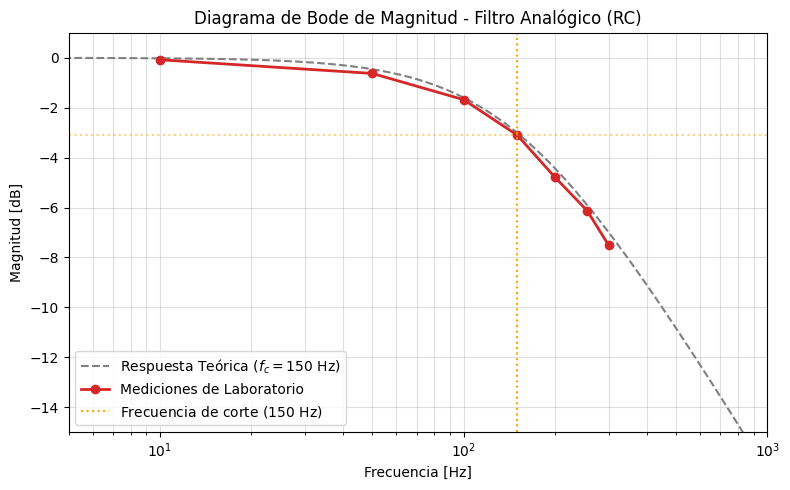

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Datos medidos en el laboratorio (Celda analógica individual)
freq_medida = np.array([10, 50, 100, 150, 200, 255, 300])
# Los valores de atenuación dados son positivos, los pasamos a negativos para el Bode
mag_medida_db = -np.array([0.079, 0.627, 1.679, 3.098, 4.795, 6.126, 7.510])

# 2. Curva teórica para comparar (Filtro RC pasabajos con fc = 150 Hz)
fc = 150.0
f_teo = np.logspace(0.5, 3, 500) # Desde ~3 Hz hasta 1000 Hz
# Ecuación de magnitud en dB para un polo real: -10 * log10(1 + (f/fc)^2)
mag_teorica_db = -10 * np.log10(1 + (f_teo / fc)**2)

# 3. Creación del gráfico
plt.figure(figsize=(8, 5))

# Ploteo de la teoría vs realidad
plt.semilogx(f_teo, mag_teorica_db, label='Respuesta Teórica ($f_c = 150$ Hz)', color='gray', linestyle='--')
plt.semilogx(freq_medida, mag_medida_db, 'o-', label='Mediciones de Laboratorio', color='#d62728', linewidth=2, markersize=6)

# Marcas de referencia importantes
plt.axvline(150, color='orange', linestyle=':', label='Frecuencia de corte ($150$ Hz)')
plt.axhline(-3.098, color='orange', linestyle=':', alpha=0.5)

# Formato del gráfico
plt.title('Diagrama de Bode de Magnitud - Filtro Analógico (RC)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which='both', axis='both', alpha=0.4)
plt.xlim(5, 1000)
plt.ylim(-15, 1)
plt.legend(loc='lower left')
plt.tight_layout()

# Guardar la imagen (opcional, para incluirla en el informe luego)
out_path = Path("img/filtro_rc_medicion.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150)

plt.show()

### 4. Procedimiento de Medición del Sistema Completo

Para evaluar el desempeño real del algoritmo DSP ejecutándose en el microcontrolador junto con sus etapas analógicas, se procedió a medir la respuesta en frecuencia de toda la cadena:

$$\text{Generador} \rightarrow \text{Filtro anti-alias} \rightarrow \text{ADC} \rightarrow \text{Filtro digital IIR} \rightarrow \text{DAC} \rightarrow \text{Filtro de reconstrucción} \rightarrow \text{Osciloscopio}$$

#### Conexionado del sistema

El conexionado se realizó siguiendo el flujo de la señal desde el generador hasta el instrumento de medición. En primer lugar, el generador de señales se conectó a la entrada de la red RC anti-alias. Esta red limita las componentes de alta frecuencia antes del muestreo y su salida se conectó al pin de entrada analógica del kit. La señal se configuró con un offset cercano a $1.65\text{ V}$ para que quedara centrada dentro del rango unipolar del ADC, entre $0$ y $3.3\text{ V}$.

Dentro de la NUCLEO-F446RE, el ADC digitaliza la señal presente en `PA0`. El firmware procesa las muestras a la frecuencia de muestreo configurada ($f_s=1000\text{ Hz}$) mediante el filtro IIR correspondiente: el Chebyshev pasabajos para el Filtro A o el notch de $50\text{ Hz}$ para el Filtro B. La muestra procesada se envía luego al DAC a través de `PA4`.

La salida del DAC se conectó a la segunda red RC, utilizada como filtro de reconstrucción o interpolación. Esta etapa reduce las componentes de alta frecuencia asociadas a la retención de orden cero del DAC y entrega una señal analógica más suave. Finalmente, la salida de este filtro se conectó al canal de medición del osciloscopio o del analizador de audio. Todas las mediciones se realizaron con una referencia de masa común entre el generador, la placa, los filtros y los instrumentos.

#### Pinout utilizado en el kit de desarrollo

Las conexiones eléctricas principales de la NUCLEO-F446RE fueron las siguientes:

| Conector y pin | Señal | Conexión realizada |
| :--- | :--- | :--- |
| **CN6 - PIN 6** | GND | Masa común del generador, las redes RC, la STM32 y el instrumento de medición. |
| **CN6 - PIN 4** | +5 VDC | Alimentación de la placa desde la fuente utilizada en el montaje. |
| **CN8 - PIN 1** | ADC_IN (`PA0`) | Entrada del ADC. Se conecta a la salida del filtro anti-alias. |
| **CN8 - PIN 3** | DAC_OUT (`PA4`) | Salida del DAC. Se conecta a la entrada del filtro de reconstrucción. |

En forma resumida, el recorrido de las conexiones fue:

1. El terminal de señal del generador se conectó a la entrada del filtro anti-alias.
2. La salida del filtro anti-alias se conectó a **CN8 - PIN 1 (ADC_IN / PA0)**.
3. El terminal de masa del generador se conectó a **CN6 - PIN 6 (GND)**, compartiendo la referencia con la placa y los filtros.
4. La alimentación de la placa se realizó mediante **CN6 - PIN 4 (+5 VDC)** y **CN6 - PIN 6 (GND)**.
5. **CN8 - PIN 3 (DAC_OUT / PA4)** se conectó a la entrada del filtro de reconstrucción.
6. La salida del filtro de reconstrucción se conectó al osciloscopio o analizador de audio para observar $V_{out}$.

> **Precaución:** antes de energizar el sistema se verificó la continuidad de la masa común y la polaridad de la alimentación. La señal aplicada al ADC se mantuvo dentro del rango de $0$ a $3.3\text{ V}$, utilizando el offset de $1.65\text{ V}$ y una amplitud aproximada de $3.0\text{ Vpp}$ para evitar saturar la entrada.

#### Pasos seguidos en el laboratorio:
1. **Conexionado:** Se conectó el generador de señales a la placa a través del filtro analógico pasabajos de entrada, y la salida del microcontrolador al osciloscopio pasando por el filtro analógico de reconstrucción.
2. **Configuración del Generador de Señales:** Se inyectó una señal senoidal ajustando un nivel de **offset de $\approx 1.65\text{ V}$** para asegurar que la señal sea unipolar y esté centrada en la mitad de la escala del ADC ($0$ a $3.3\text{ V}$). La amplitud se fijó en **$\approx 3.0\text{ Vpp}$** ($3.3\text{ Vpp}$ según las mediciones registradas) para maximizar el rango dinámico sin saturar el conversor.
3. **Calibración del osciloscopio y compensación de las puntas:** Antes de medir el circuito se conectó cada punta a la señal cuadrada de calibración o prueba provista por el propio osciloscopio. Se ajustó la compensación de ambas puntas hasta obtener una onda cuadrada sin sobreimpulso ni redondeo apreciable. También se verificó que los dos canales indicaran correctamente la amplitud y la referencia de cero, descartando atenuaciones adicionales o errores introducidos por una compensación inadecuada.
4. **Configuración del Osciloscopio:** Una vez compensadas las puntas, se utilizaron dos canales simultáneos para medir el voltaje pico a pico a la entrada ($V_{in}$) y a la salida final ($V_{out}$). Se mantuvo la misma configuración de atenuación de las puntas en el menú del osciloscopio que la indicada físicamente en ellas. Para las frecuencias en las que la señal de salida se encontraba muy atenuada y próxima al nivel de ruido, se activó el modo de promediado del osciloscopio. Esta función permitió obtener una visualización más precisa de la señal residual y reducir la influencia del ruido aleatorio en la lectura de amplitud.
5. **Barrido de Frecuencias:** Se varió la frecuencia del generador manualmente tomando puntos estratégicos: un barrido fino alrededor del Notch ($50\text{ Hz}$), y un barrido a lo largo de las bandas de paso, transición y rechazo del Chebyshev.

#### Resultados obtenidos

**Mediciones Filtro B (Notch $50\text{ Hz}$)**

| Frecuencia [Hz] | $V_{in}$ [Vpp] | $V_{out}$ [Vpp] | Relación ($V_{out}/V_{in}$) | Atenuación [dB] |
| :---: | :---: | :---: | :---: | :---: |
| 10 | 3.3 | 3.30 | 1.000 | 0.00 |
| 25 | 3.3 | 3.27 | 0.990 | -0.07 |
| 35 | 3.3 | 3.24 | 0.981 | -0.15 |
| 45 | 3.3 | 3.20 | 0.969 | -0.26 |
| 48 | 3.3 | 3.07 | 0.930 | -0.62 |
| **50** | **3.3** | **0.10** | **0.030** | **-30.37** |
| 51 | 3.3 | 2.70 | 0.818 | -1.74 |
| 55 | 3.3 | 3.00 | 0.909 | -0.82 |
| 65 | 3.3 | 3.00 | 0.909 | -0.82 |
| 75 | 3.3 | 2.90 | 0.878 | -1.12 |

**Mediciones Filtro A (Chebyshev Pasabajos)**

| Frecuencia [Hz] | $V_{in}$ [Vpp] | $V_{out}$ [Vpp] | Relación ($V_{out}/V_{in}$) | Atenuación [dB] |
| :---: | :---: | :---: | :---: | :---: |
| 5 | 3.3 | 3.00 | 0.909 | -0.82 |
| 10 | 3.3 | 3.00 | 0.909 | -0.82 |
| 15 | 3.3 | 3.03 | 0.918 | -0.74 |
| 20 | 3.3 | 3.07 | 0.930 | -0.62 |
| 25 | 3.3 | 3.11 | 0.942 | -0.51 |
| 30 | 3.3 | 3.16 | 0.957 | -0.37 |
| 35 | 3.3 | 3.20 | 0.969 | -0.26 |
| 40 | 3.3 | 3.16 | 0.957 | -0.37 |
| 45 | 3.3 | 3.07 | 0.930 | -0.62 |
| 50 | 3.3 | 3.00 | 0.909 | -0.82 |
| 75 | 3.3 | 2.59 | 0.784 | -2.10 |
| **100** | **3.3** | **2.48** | **0.751** | **-2.48** |
| 150 | 3.3 | 0.20 | 0.060 | -24.34 |
| 200 | 3.3 | 0.016 | 0.004 | -46.28 |
| 250 | 3.3 | 0.004 | 0.001 | -58.32 |
| **300** | **3.3** | **0.004** | **0.001** | **-58.32** |

*(Nota: A partir de los $250\text{ Hz}$ el valor medido de $4\text{ mVpp}$ corresponde al piso de ruido del instrumento/sistema, logrando evidenciar un rechazo práctico cercano a los $60\text{ dB}$).* 

#### Corrección de la atenuación de los filtros analógicos

Las mediciones de las tablas corresponden a la cadena completa y, por lo tanto, incluyen la atenuación de los dos filtros RC activos: el filtro anti-alias ubicado antes del ADC y el filtro de interpolación o reconstrucción ubicado después del DAC. Por este motivo, la atenuación medida no representa exclusivamente al filtro digital.

Para estimar la respuesta del algoritmo DSP se descontó la atenuación teórica de ambos filtros, suponiendo que son filtros RC de primer orden idénticos con $f_c \approx 150\text{ Hz}$:

$$A_{RC,\,cascada}(f)=2\left[-10\log_{10}\left(1+\left(\frac{f}{150\text{ Hz}}\right)^2\right)\right]$$

La magnitud corregida se calculó como:

$$A_{DSP,\,estimada}(f)=A_{medida,\,total}(f)-A_{RC,\,cascada}(f)$$

Por ejemplo, a $100\text{ Hz}$ los dos filtros RC introducen aproximadamente $-3.18\text{ dB}$ en cascada. La medición total de $-2.48\text{ dB}$ para el Filtro A se transforma entonces en una respuesta estimada del filtro digital de aproximadamente $+0.70\text{ dB}$. Esta corrección es una estimación basada en $f_c=150\text{ Hz}$; las diferencias entre los valores nominales y medidos de los componentes, el piso de ruido y la carga del circuito pueden producir pequeñas discrepancias.

#### Respuesta corregida del sistema digital estimada

<div align="center">
  <img src="img/medicion_filtro_A_corregida.png" alt="Respuesta del filtro A corregida por la atenuacion de los filtros RC" width="60%"/>
</div>

*Figura: Respuesta estimada del filtro A luego de descontar la atenuación de los filtros anti-alias e interpolación. La curva representa de manera más aproximada el comportamiento del filtro digital Chebyshev implementado en la STM32.*

<div align="center">
  <img src="img/medicion_filtro_B_corregida.png" alt="Respuesta del filtro B corregida por la atenuacion de los filtros RC" width="60%"/>
</div>

*Figura: Respuesta estimada del filtro B luego de descontar la atenuación introducida por las dos etapas RC. La muesca de 50 Hz se mantiene, ya que la corrección afecta principalmente la atenuación de las frecuencias fuera de la frecuencia de rechazo.*

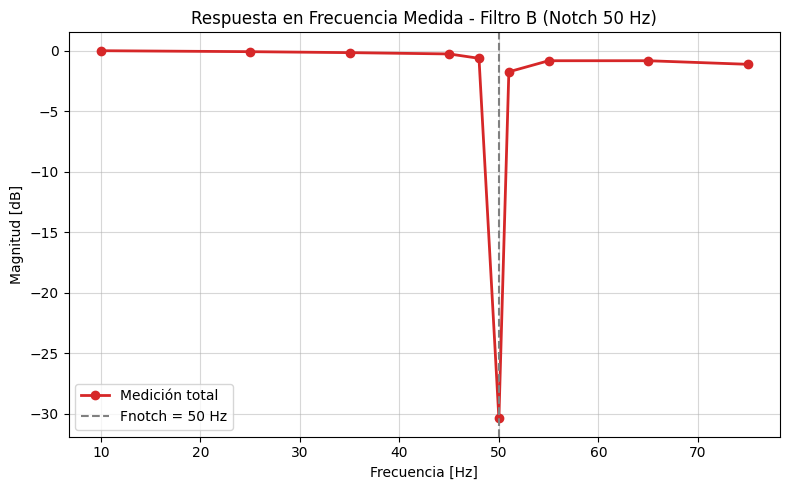

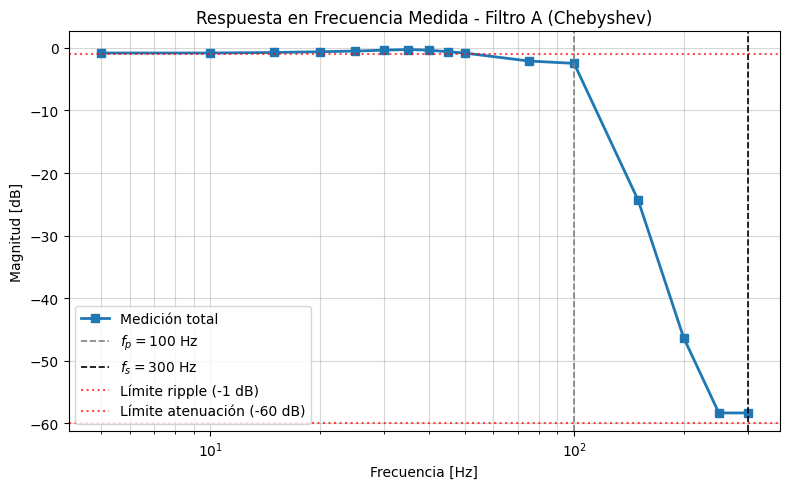

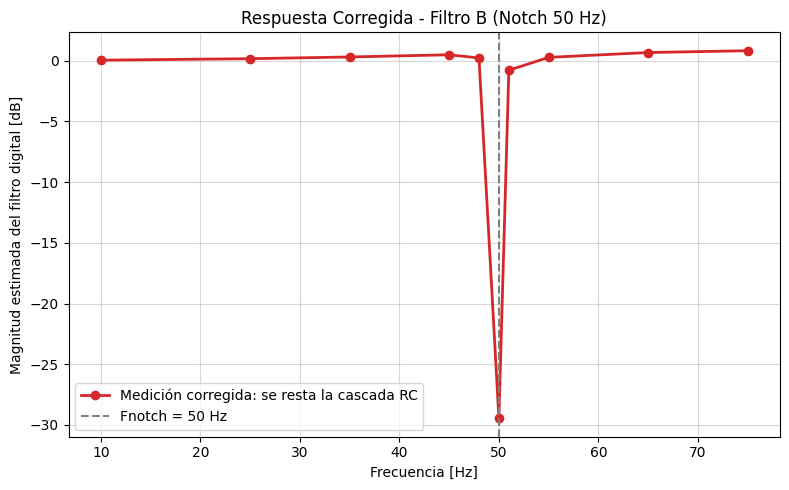

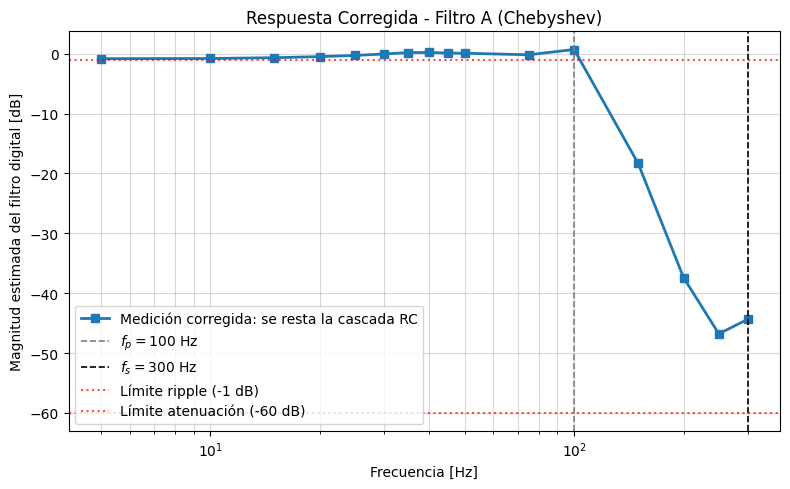

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- DATOS FILTRO B (NOTCH 50 Hz) ---
freq_notch = np.array([10, 25, 35, 45, 48, 50, 51, 55, 65, 75])
mag_notch_db = np.array([0.0, -0.079, -0.159, -0.267, -0.627, -30.370, -1.743, -0.827, -0.827, -1.122])

# --- DATOS FILTRO A (CHEBYSHEV PASABAJOS) ---
# Se omite el duplicado de 50 Hz de la tabla para mantener el array ordenado.
freq_cheby = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150, 200, 250, 300])
mag_cheby_db = np.array([-0.827, -0.827, -0.741, -0.627, -0.515, -0.376, -0.267, -0.376, -0.627, -0.827, -2.104, -2.481, -24.349, -46.287, -58.329, -58.329])

# Los dos filtros RC son iguales y se consideran en cascada.
FC_ANALOGICA = 150.0

def atenuacion_rc_cascada_db(frecuencias_hz: np.ndarray) -> np.ndarray:
    """Calcula la atenuacion de dos filtros RC identicos en cascada."""
    atenuacion_un_filtro_db = -10 * np.log10(1 + (frecuencias_hz / FC_ANALOGICA) ** 2)
    return 2 * atenuacion_un_filtro_db


def corregir_atenuacion_analogica(frecuencias_hz: np.ndarray, magnitud_medida_db: np.ndarray) -> np.ndarray:
    """Extrae la respuesta estimada del filtro digital de la medicion total."""
    return magnitud_medida_db - atenuacion_rc_cascada_db(frecuencias_hz)


def plot_mediciones_notch():
    plt.figure(figsize=(8, 5))
    plt.plot(freq_notch, mag_notch_db, 'o-', color='#d62728', linewidth=2, markersize=6, label='Medición total')
    plt.axvline(50, color='gray', linestyle='--', linewidth=1.5, label='Fnotch = 50 Hz')
    plt.title('Respuesta en Frecuencia Medida - Filtro B (Notch 50 Hz)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud [dB]')
    plt.grid(True, which='both', axis='both', alpha=0.5)
    plt.legend(loc='lower left')
    plt.tight_layout()
    out_path = Path("img/medicion_filtro_B.png")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


def plot_mediciones_cheby():
    plt.figure(figsize=(8, 5))
    plt.semilogx(freq_cheby, mag_cheby_db, 's-', color='#1f77b4', linewidth=2, markersize=6, label='Medición total')
    plt.axvline(100, color='gray', linestyle='--', linewidth=1.2, label='$f_p = 100$ Hz')
    plt.axvline(300, color='black', linestyle='--', linewidth=1.2, label='$f_s = 300$ Hz')
    plt.axhline(-1.0, color='red', linestyle=':', alpha=0.7, label='Límite ripple (-1 dB)')
    plt.axhline(-60.0, color='red', linestyle=':', alpha=0.7, label='Límite atenuación (-60 dB)')
    plt.title('Respuesta en Frecuencia Medida - Filtro A (Chebyshev)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud [dB]')
    plt.grid(True, which='both', axis='both', alpha=0.5)
    plt.legend(loc='lower left')
    plt.tight_layout()
    out_path = Path("img/medicion_filtro_A.png")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


def plot_mediciones_corregidas():
    """Grafica la respuesta estimada de los filtros digitales sin la perdida RC."""
    mag_notch_corregida_db = corregir_atenuacion_analogica(freq_notch, mag_notch_db)
    mag_cheby_corregida_db = corregir_atenuacion_analogica(freq_cheby, mag_cheby_db)

    plt.figure(figsize=(8, 5))
    plt.plot(freq_notch, mag_notch_corregida_db, 'o-', color='#d62728', linewidth=2, markersize=6,
             label='Medición corregida: se resta la cascada RC')
    plt.axvline(50, color='gray', linestyle='--', linewidth=1.5, label='Fnotch = 50 Hz')
    plt.title('Respuesta Corregida - Filtro B (Notch 50 Hz)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud estimada del filtro digital [dB]')
    plt.grid(True, which='both', axis='both', alpha=0.5)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig('img/medicion_filtro_B_corregida.png', dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.semilogx(freq_cheby, mag_cheby_corregida_db, 's-', color='#1f77b4', linewidth=2, markersize=6,
                 label='Medición corregida: se resta la cascada RC')
    plt.axvline(100, color='gray', linestyle='--', linewidth=1.2, label='$f_p = 100$ Hz')
    plt.axvline(300, color='black', linestyle='--', linewidth=1.2, label='$f_s = 300$ Hz')
    plt.axhline(-1.0, color='red', linestyle=':', alpha=0.7, label='Límite ripple (-1 dB)')
    plt.axhline(-60.0, color='red', linestyle=':', alpha=0.7, label='Límite atenuación (-60 dB)')
    plt.title('Respuesta Corregida - Filtro A (Chebyshev)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud estimada del filtro digital [dB]')
    plt.grid(True, which='both', axis='both', alpha=0.5)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig('img/medicion_filtro_A_corregida.png', dpi=150)
    plt.show()


# Generar gráficos de la medición total y de la respuesta corregida.
plot_mediciones_notch()
plot_mediciones_cheby()
plot_mediciones_corregidas()


### Registro fotográfico de la práctica de laboratorio

A continuación se presentan las fotografías tomadas durante la implementación y verificación experimental del sistema de filtrado digital. Las imágenes documentan la placa STM32, las redes analógicas externas, los instrumentos utilizados y las respuestas medidas para los filtros A y B.

#### 1. Placa de desarrollo STM32 NUCLEO-F446RE

<div align="center">
  <img src="img/stm.jpeg" alt="Placa de desarrollo STM32 NUCLEO-F446RE" width="60%"/>
</div>

*Figura: Placa NUCLEO-F446RE utilizada para ejecutar el algoritmo de filtrado digital IIR. La entrada se adquiere mediante el ADC y la señal procesada se entrega mediante el DAC.*

#### 2. Montaje experimental completo

<div align="center">
  <img src="img/stm_filtros.jpeg" alt="Montaje experimental con la placa STM32 y los filtros analogicos" width="60%"/>
</div>

*Figura: Montaje de laboratorio formado por la placa STM32, las redes RC de entrada y salida, y los cables de conexión utilizados para realizar las mediciones. Las redes analógicas cumplen las funciones de filtro anti-alias e interpolación o reconstrucción.*

#### 3. Osciloscopio utilizado en la práctica

<div align="center">
  <img src="img/osciloscopio.jpeg" alt="Osciloscopio utilizado durante la practica" width="60%"/>
</div>

*Figura: Osciloscopio utilizado para observar las señales de entrada y salida del sistema y verificar sus amplitudes durante las mediciones experimentales.*

#### 4. Generador de señales

<div align="center">
  <img src="img/geneardor_señales.jpeg" alt="Generador de señales utilizado para inyectar la señal" width="60%"/>
</div>

*Figura: Generador de señales utilizado para inyectar al sistema las señales senoidales de distintas frecuencias. La señal se aplicó a la entrada del filtro anti-alias y luego fue procesada por el ADC, el filtro digital IIR y el DAC. Para evitar saturaciones del conversor, se utilizó un offset cercano a 1.65 V.*

#### 5. Analizador de audio Agilent U8903A

<div align="center">
  <img src="img/notch_1.jpeg" alt="Analizador de audio Agilent U8903A" width="60%"/>
</div>

*Figura: Analizador de audio Agilent U8903A utilizado para medir la respuesta en frecuencia. El equipo permite observar la magnitud de la señal y utilizar marcadores para determinar la atenuación en frecuencias específicas.*

#### 6. Respuesta medida del filtro notch a 50 Hz

<div align="center">
  <img src="img/notch_2.jpeg" alt="Respuesta del filtro notch medida alrededor de 50 Hz" width="60%"/>
</div>

*Figura: Respuesta experimental del filtro B en el intervalo de 45 Hz a 55 Hz. El marcador indica una atenuación aproximada de -27 dB en 50 Hz, confirmando el rechazo de la interferencia de red.*

#### 7. Respuesta medida del filtro pasabajos Chebyshev

<div align="center">
  <img src="img/lpf_cheby_1.jpeg" alt="Respuesta del filtro Chebyshev medida hasta 400 Hz" width="60%"/>
</div>

*Figura: Respuesta experimental del filtro A entre aproximadamente 90 Hz y 400 Hz. Se observa la caída progresiva de la magnitud y una atenuación cercana a -51.3 dB alrededor de 309.3 Hz, próxima al inicio de la banda de rechazo especificada.*

<div align="center">
  <img src="img/lpf_cheby_2.jpeg" alt="Respuesta ampliada del filtro Chebyshev" width="60%"/>
</div>

*Figura: Segunda captura de la respuesta del filtro A. La medición confirma el comportamiento pasabajos y la atenuación elevada en las frecuencias superiores a la banda de paso.*

En conjunto, las fotografías muestran la cadena completa de medición: generación e inyección de la señal, filtrado analógico de entrada, conversión ADC, procesamiento IIR en la STM32, conversión DAC, filtrado de reconstrucción y análisis de la respuesta en frecuencia.

<a id="p4"></a>

***

## 4. Conclusiones

En este trabajo se diseñaron e implementaron dos filtros digitales IIR sobre la placa STM32 NUCLEO-F446RE utilizando la librería CMSIS-DSP. El Filtro A, diseñado como un pasabajos Chebyshev tipo I, cumplió en simulación con las especificaciones de banda de paso hasta $100\text{ Hz}$ y atenuación superior a $60\text{ dB}$ desde $300\text{ Hz}$. El Filtro B permitió obtener una muesca centrada en $50\text{ Hz}$, destinada a rechazar la interferencia asociada a la frecuencia de red.

La conversión de los coeficientes desde el formato SOS de SciPy al formato requerido por `arm_biquad_cascade_df1_f32` permitió utilizar las secciones biquad en punto flotante de 32 bits. La implementación en el microcontrolador integró la adquisición mediante ADC, el procesamiento por bloques y la salida mediante DAC, manteniendo la señal centrada alrededor de la mitad de la escala para evitar saturaciones.

Las mediciones experimentales confirmaron el comportamiento esperado: el Filtro B presentó un rechazo pronunciado alrededor de $50\text{ Hz}$ y el Filtro A mostró una atenuación creciente en la banda de rechazo, alcanzando valores cercanos a $-60\text{ dB}$ alrededor de $300\text{ Hz}$. Sin embargo, la respuesta medida inicialmente correspondía a la cadena completa y también incluía la atenuación de los filtros RC anti-alias e interpolación.

Al descontar la atenuación teórica de ambos filtros analógicos, considerando una frecuencia de corte aproximada de $150\text{ Hz}$, se obtuvo una estimación más representativa de la respuesta propia del procesamiento digital. Esta corrección permite distinguir el aporte del algoritmo IIR del efecto de las etapas analógicas, aunque sus resultados deben interpretarse como una estimación debido a las tolerancias de los componentes, la carga del circuito y el piso de ruido de los instrumentos.

#### Diferencias entre la respuesta teórica y las mediciones

La respuesta teórica, la respuesta observada con el osciloscopio y la respuesta obtenida con el analizador de audio no coinciden exactamente y eso es esperable. La simulación representa un filtro ideal con coeficientes exactos, frecuencia de muestreo fija y sin incluir las imperfecciones del ADC, el DAC, las redes RC ni los instrumentos de medición.

En cambio, el osciloscopio mide directamente las señales analógicas $V_{in}$ y $V_{out}$ en el montaje real. Por lo tanto, su resultado incluye la tolerancia de resistencias y capacitores, la impedancia de las puntas, la carga del circuito, el ruido eléctrico, la resolución vertical y el piso de ruido del instrumento. Cuando la señal queda muy atenuada, la lectura puede acercarse al piso de ruido, por lo que el valor medido deja de representar únicamente la señal filtrada. El modo de promediado ayuda a reducir el ruido aleatorio, pero no elimina errores sistemáticos ni recupera información que se encuentre por debajo de la resolución del instrumento.

El analizador de audio utiliza otro método de adquisición y procesamiento. Puede calcular la magnitud espectral mediante muestreo interno, ventanas, promediado y filtros de resolución, por lo que la lectura depende de su ancho de banda de resolución, tiempo de integración, rango dinámico y configuración del barrido. Además, su cadena de entrada, impedancia y calibración pueden diferir de las del osciloscopio. Por ello, el analizador suele mostrar una curva más selectiva o estable en frecuencia, mientras que el osciloscopio permite observar directamente la forma de onda y medir amplitudes en el dominio temporal.

En consecuencia, las diferencias entre los instrumentos no indican necesariamente un funcionamiento incorrecto del filtro. Se deben comparar las tendencias principales, la frecuencia del notch, la frecuencia de corte y los niveles de rechazo, considerando siempre la resolución, el ruido, la atenuación de los filtros analógicos y la configuración de cada instrumento. La calibración del osciloscopio, la compensación de sus puntas y el uso del promediado en señales débiles reducen parte de estas diferencias, pero no hacen que ambas mediciones sean idénticas.

En conclusión, se verificó experimentalmente la integración entre el diseño matemático, la implementación digital en la STM32 y las etapas analógicas necesarias para acondicionar las señales. El sistema completo cumplió con los objetivos de filtrado planteados y permitió observar en laboratorio las diferencias entre la respuesta ideal simulada y el comportamiento real del conjunto.